In [211]:
## Unscented Kalman Filter
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm

np.random.seed(711)  # For reproducibility

"""
1) Current Estimate -> Sigma Points
2) Propagate Sigma Points through state transition Function (f)
3) Predicted Measurement -> Propagated Sigma Points through measurement function (h)
4) Compare Predicted Measurement with Actual Measurement
5) Update Current Estimate and Covariance with Kalman Gain
6) Repeat

"""


'\n1) Current Estimate -> Sigma Points\n2) Propagate Sigma Points through state transition Function (f)\n3) Predicted Measurement -> Propagated Sigma Points through measurement function (h)\n4) Compare Predicted Measurement with Actual Measurement\n5) Update Current Estimate and Covariance with Kalman Gain\n6) Repeat\n\n'

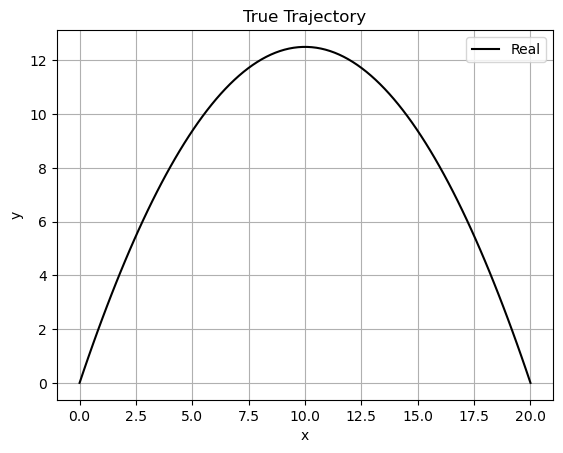

In [212]:
# True trajectory
pts = 100
t = np.linspace(0,10,pts)
dt = t[1] - t[0]
xTrue = t*2
yTrue = 5*t - 0.5*t**2
vxTrue = np.ones(pts) * 2
vyTrue = 5 - t
stateTrue = np.vstack((xTrue, yTrue, vxTrue, vyTrue))  # Now a proper 4x100 array

plt.figure(1)
plt.plot(xTrue,yTrue,'k-',label='Real')
plt.xlabel('x')
plt.ylabel('y')
plt.title('True Trajectory')
plt.legend()
plt.grid()
plt.show()

In [213]:
def f(state, dt): # State transition function
    x, y, vx, vy = state
    new_x = x + vx * dt
    new_y = y + vy * dt
    new_vx = vx
    new_vy = vy - 1.0 * dt
    return np.array([new_x, new_y, new_vx, new_vy])

def h(state): # Measurement function
    x, y = state[0], state[1]
    range_ = np.sqrt(x**2 + y**2)
    bearing = np.arctan2(y, x)
    return np.array([range_, bearing])

# Sigma Vectors
def sigma(mean, cov, L, lam):
    S = sqrtm((L + lam) * cov)  # Calculate once
    X = [mean]  # X0 (index 0)
    for i in range(L):
       X.append(mean + S[i])  # X1 to XL
    for i in range(L):
       X.append(mean - S[i])  # XL+1 to X2L
    return X

def wrap_angle(a):
    return (a + np.pi) % (2 * np.pi) - np.pi

def angle_mean(angles, weights):
    sin_sum = np.sum(weights * np.sin(angles))
    cos_sum = np.sum(weights * np.cos(angles))
    return np.arctan2(sin_sum, cos_sum)

In [214]:
## Unscented Transformation
init = np.array([xTrue[0], yTrue[0], 2, 5], dtype=float)  # x, y, vx, vy

# Process Noise (trust in sys model)
Q = np.array([
   [0.1, 0.0, 0.0, 0.0],
   [0.0, 0.1, 0.0, 0.0],
   [0.0, 0.0, 0.5, 0.0],
   [0.0, 0.0, 0.0, 0.5],
])

# Measurement Noise (trust in sensors)
R = np.array([
   [0.1, 0.0],   # Range error
   [0.0, 0.01],  # Bearing error
], dtype=float)

L = len(init)
alpha = 1e-3
kappa = 0
lam = alpha**2 * (L + kappa) - L
beta = 2

# Weights
W_m = [lam / (L + lam)]
W_c = [W_m[0] + (1 - alpha**2 + beta)]
for j in range(2 * L):
   W_m.append(1 / (2 * (L + lam)))
   W_c.append(1 / (2 * (L + lam)))

W_m = np.array(W_m, dtype=float)
W_c = np.array(W_c, dtype=float)

# main
state = init.copy()
cv = np.eye(4) * 0.1
history = []
measurements = []

for i in range(pts):
   ## 1) Prediction
   sig = sigma(state, cv, L, lam)

   S_pred = []
   for s in sig: # run sigma value through state transition function
      S_pred.append(f(s, dt))
   S_pred = np.array(S_pred)

   mean_pred = np.zeros(L)
   for j in range(2 * L + 1): # compute predicted state mean via weighted sum of predicted sigma points
      mean_pred += W_m[j] * S_pred[j]

   cv_pred = np.zeros((L, L))
   for j in range(2 * L + 1):
      diff = S_pred[j] - mean_pred
      cv_pred += W_c[j] * np.outer(diff, diff) # compute predicted state covariance via weighted sum of outer products of differences
   cv_pred += Q



   ## 2) Update Step (Predicted Measurement - heart of the UKF)
   S_meas = []
   for s in S_pred: # run predicted sigma points through measurement function
      S_meas.append(h(s))
   S_meas = np.array(S_meas)

   # Predicted measurement mean (range linear, bearing circular)
   pred_meas = np.zeros(2)
   for j in range(2 * L + 1):
      pred_meas[0] += W_m[j] * S_meas[j][0]  # range
      pred_meas[1] = angle_mean(S_meas[:, 1], W_m)  # bearing

   # Predicted measurement covariance
   meas_cv = R.copy()
   for j in range(2 * L + 1):
      diff_meas = S_meas[j] - pred_meas
      diff_meas[1] = wrap_angle(diff_meas[1])
      meas_cv += W_c[j] * np.outer(diff_meas, diff_meas)

   # Cross covariance
   cross_cv = np.zeros((4, 2))
   for j in range(2 * L + 1):
      diff_pred = S_pred[j] - mean_pred
      diff_meas = S_meas[j] - pred_meas
      diff_meas[1] = wrap_angle(diff_meas[1])
      cross_cv += W_c[j] * np.outer(diff_pred, diff_meas)



   ## 3) Correction Step (Predicted Measurement vs Actual Measurement, Kalman Gain)
   K = cross_cv @ np.linalg.inv(meas_cv)

   z_true = h(stateTrue[:, i])
   z_meas = z_true + np.random.multivariate_normal([0, 0], R)
   z_meas[1] = wrap_angle(z_meas[1])
   measurements.append(z_meas)

   wrap = z_meas - pred_meas
   wrap[1] = wrap_angle(wrap[1])

   state = mean_pred + K @ wrap
   cv = cv_pred - K @ meas_cv @ K.T

   history.append(state.copy())

ukf_estimates = np.array(history)
measurements = np.array(measurements)

In [215]:
# Convert polar measurements back to XY for plotting
meas_x = measurements[:, 0] * np.cos(measurements[:, 1])
meas_y = measurements[:, 0] * np.sin(measurements[:, 1])

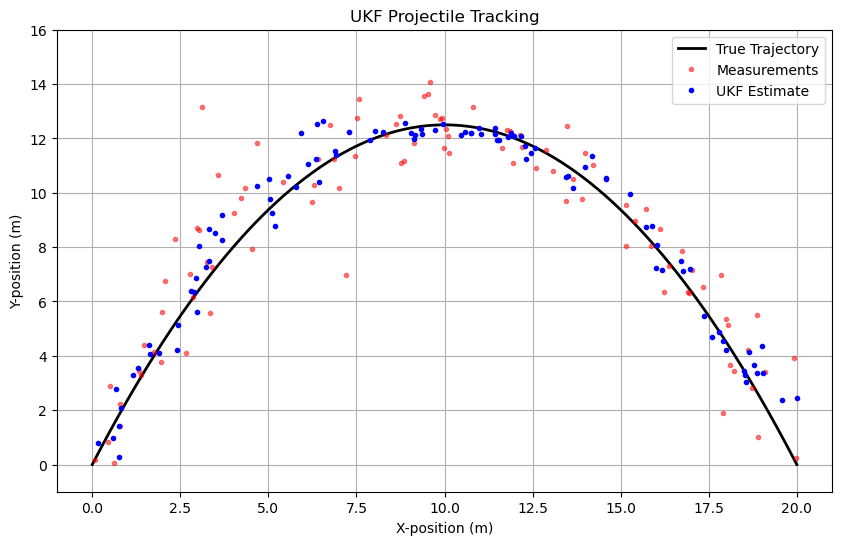

In [216]:
plt.figure(figsize=(10, 6))
plt.plot(xTrue, yTrue, 'k-', linewidth=2, label='True Trajectory')
plt.plot(meas_x, meas_y, 'r.', alpha=0.5, label='Measurements')
plt.plot(ukf_estimates[:, 0], ukf_estimates[:, 1], 'b.', label='UKF Estimate')
plt.xlabel('X-position (m)')
plt.ylabel('Y-position (m)')
plt.title('UKF Projectile Tracking')
plt.legend()
plt.ylim(-1, 16)
plt.xlim(-1, 21)
plt.grid(True)
plt.show()